In [673]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd
import sympy as sy
from sympy import sin, exp, cos
from IPython.display import display

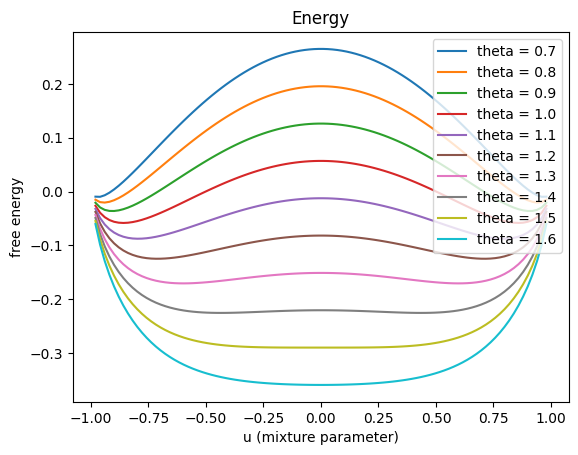

In [674]:
#logartihmic potential
temperatur_thetas = np.arange(0.7,1.7,0.1)
u = np.linspace(-1,1,100)
critical_temperature = 1.5

def log_potential(u,theta):
    l1 = (critical_temperature/2)*(1-u**2)
    l2 = (theta/2)*((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
    return l1 + l2

for theta in temperatur_thetas:
    y_vals = log_potential(u,theta)
    plt.plot(u,y_vals, label = f'theta = {np.round(theta,2)}')
    plt.legend()

plt.title("Energy")
plt.xlabel("u (mixture parameter)")
plt.ylabel("free energy")
plt.show()

In [675]:

def biharmonic_solver(Lx,Ly,Nx,Ny, F, c, mean):
    F_hat = fft2(F)
    kx = fftfreq(Nx, d=Lx/Nx) * 2 * np.pi
    ky = fftfreq(Ny, d=Ly/Ny) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2+KY**2
    KfourierSpace = (K2**2 + c)
    KfourierSpace[0,0] = 1

    u_hat = F_hat/KfourierSpace
    u_hat[0,0] = mean

    U = ifft2(u_hat).real

    return U

In [676]:
#parameters:
Nx1 = np.array([4,8,15,16,20,32])
Ny1 = 2*Nx1

k = np.arange(0,10)
Nx2 = 4+4*k
Ny2 =2*Nx2


In [677]:
#manufacture solutions: 
def manufacture_solution_biharmonic(u_string, c):
    x, y = sy.symbols('x y')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    f_symbolic = biharmonic + c*u_symbolic
    f_symbolic = sy.simplify(f_symbolic)

    u = sy.lambdify((x, y), u_symbolic, modules='numpy')
    f = sy.lambdify((x, y), f_symbolic, modules='numpy')

    return u,f


In [678]:
u1_string = 'sin(8*(x-1))*cos(4*y)'
u1,f1 = manufacture_solution_biharmonic(u1_string, c = 1)

u2_string = 'exp(sin(x)**2+cos(2*y))'
u2,f2 = manufacture_solution_biharmonic(u2_string, c = 0)

In [699]:

def compute_errors(f,NX,NY,u,c):
    errors = []
    eocs = []
    for i in range(len(NX)):
        Lx = 2*np.pi
        Ly = 4*np.pi
        Nx = NX[i]
        Ny = NY[i]
        x = np.linspace(0,Lx,Nx, endpoint=False)
        y = np.linspace(0,Ly,Ny, endpoint=False)
        X,Y = np.meshgrid(x,y, indexing="ij")

        F = f(X,Y)
        U_ex = u(X,Y)
        U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c, mean = 0)
        U += np.mean(U_ex)
        U_err = U - U_ex
        error = np.linalg.norm(U_err, np.inf)

        #append stuff
        errors.append(error)

        #convergences
        if len(errors) > 1:
            h_now = Lx / NX[i]
            h_prev = Lx / NX[i-1]
            eoc = np.log(errors[-1] / errors[-2]) / np.log(h_now / h_prev)
            eocs.append(eoc)
        else:
            eocs.append("Not yet...")

    return errors,eocs
        
errors1, eocs1 = compute_errors(f1,Nx1,Ny1,u1,c=1)
errors2, eocs2 = compute_errors(f2,Nx2,Ny2,u2,c=0)

In [700]:
df1 = pd.DataFrame({
    'Nx': Nx1,
    'Ny': Ny1,
    'Error': errors1,
    'EOC': eocs1
})

df2 = pd.DataFrame({
    'Nx': Nx2,
    'Ny': Ny2,
    'Error': errors2,
    'EOC': eocs2
})


display(df1), display(df2)

,Nx,Ny,Error,EOC
0,4,8,1.818989e-12,Not yet...
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


,Nx,Ny,Error,EOC
0,4,8,9.573099e+01,Not yet...
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775


(None, None)

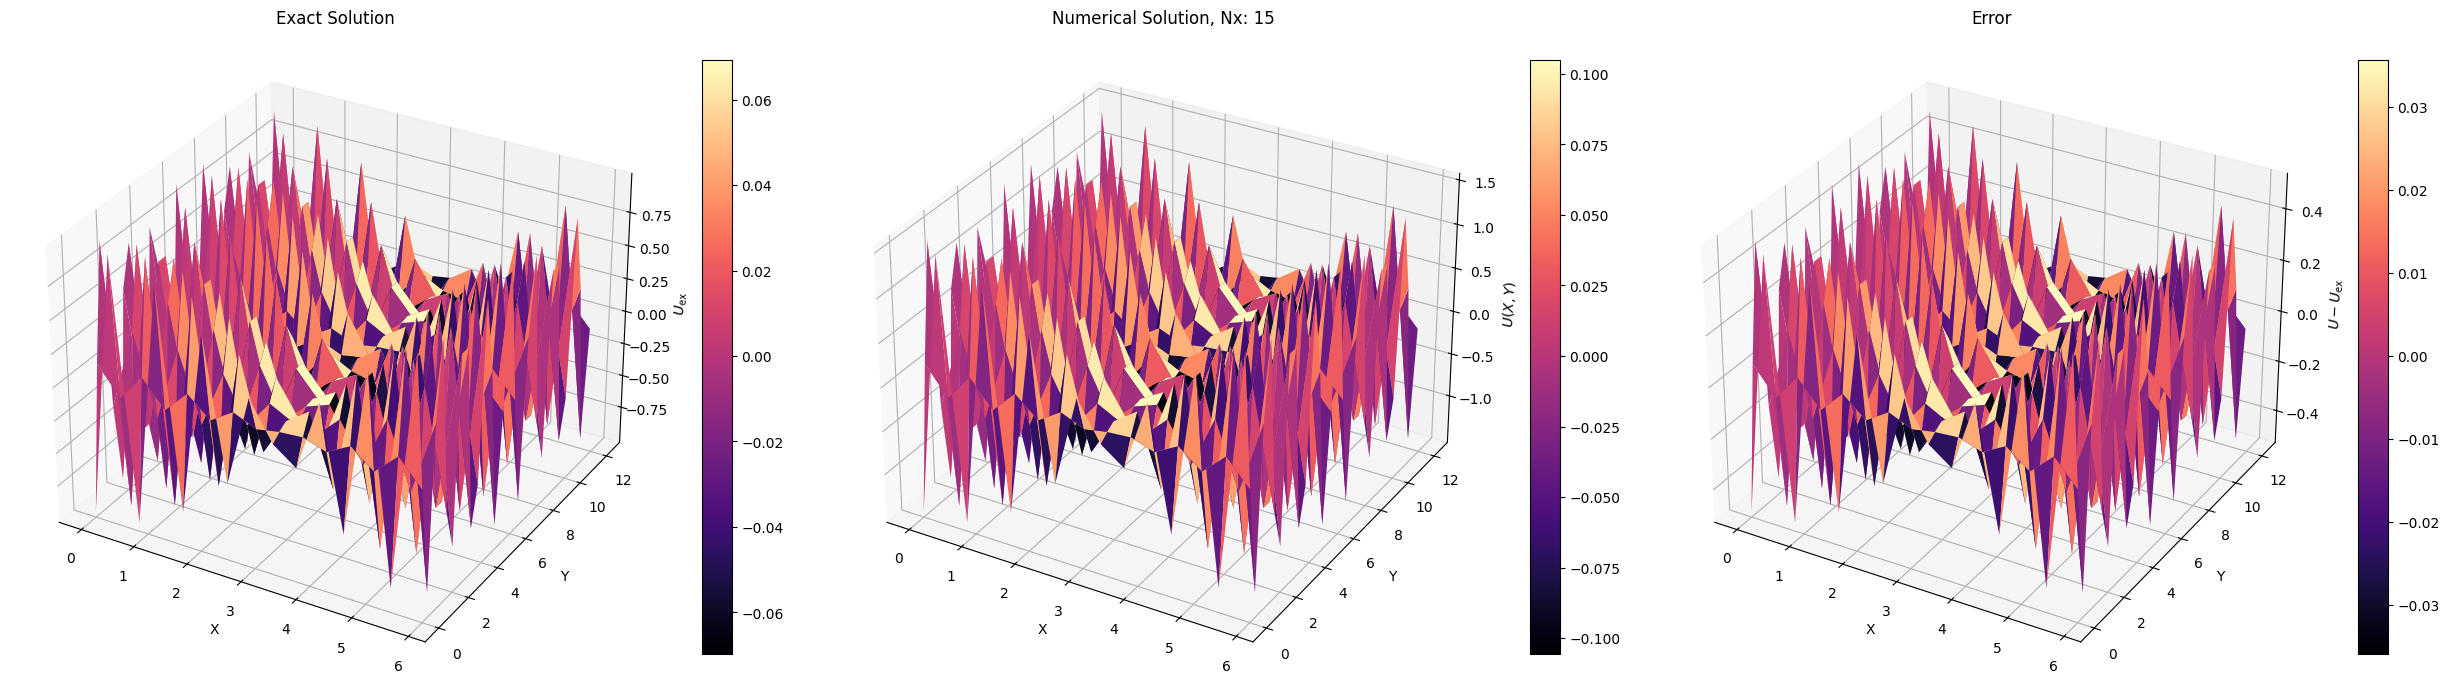

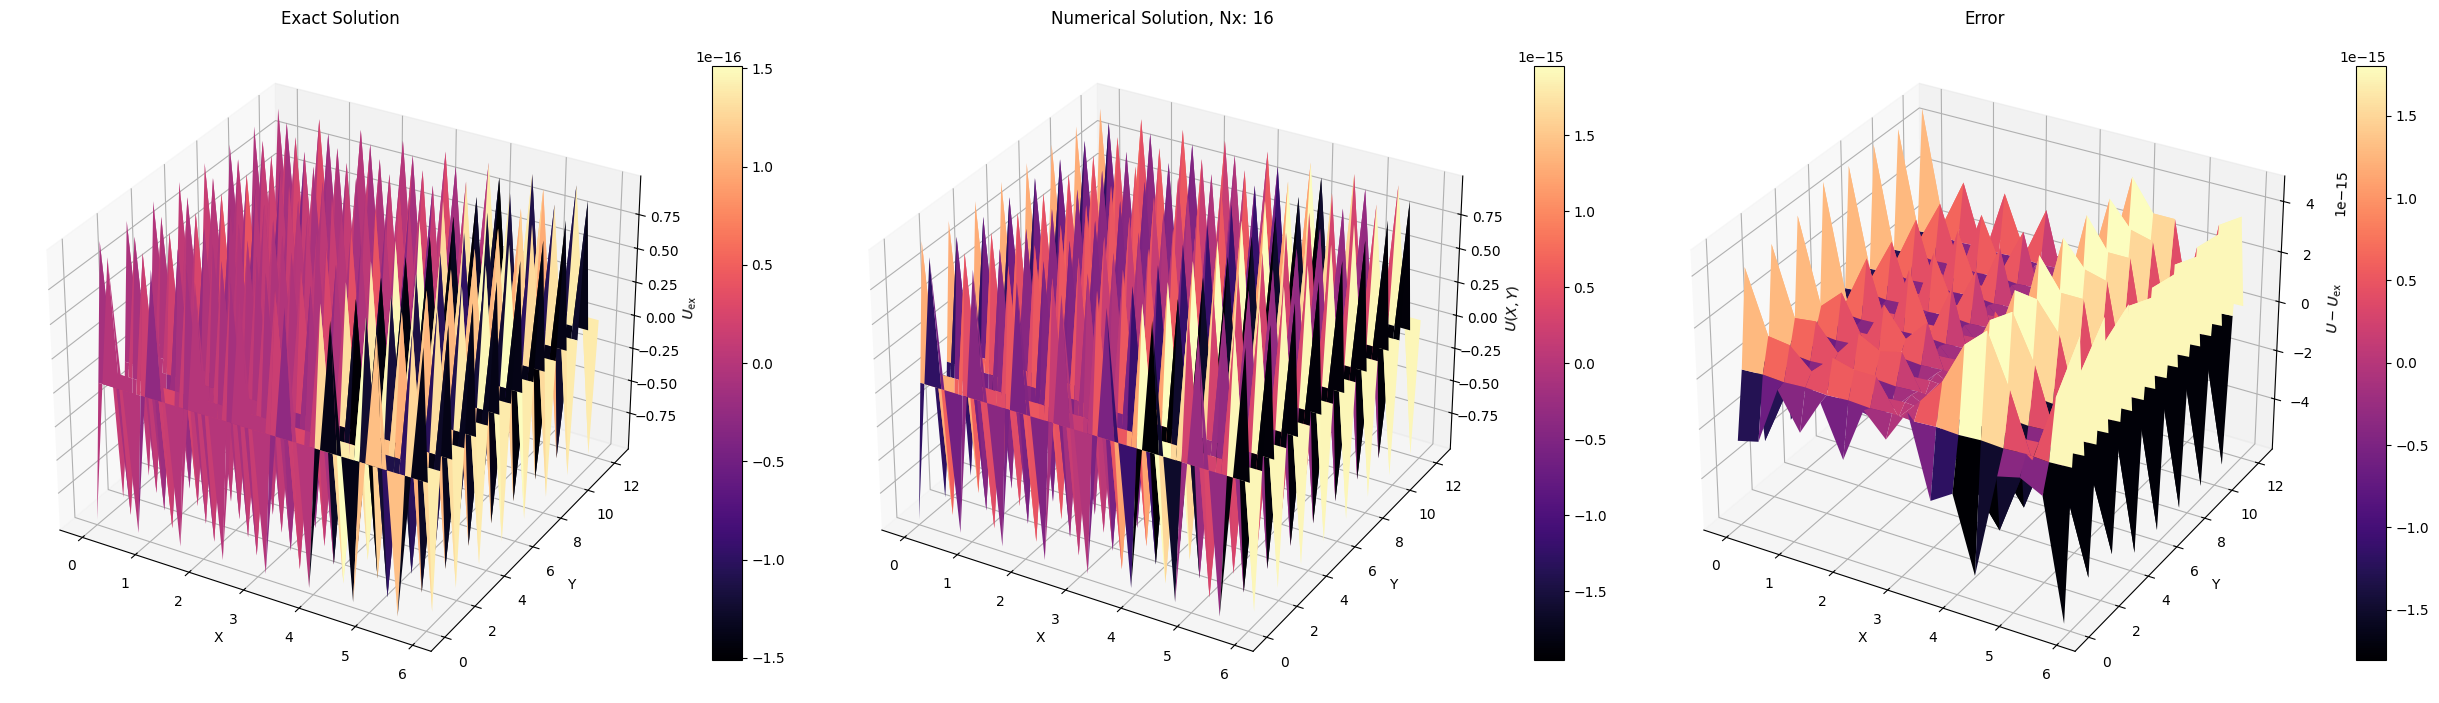

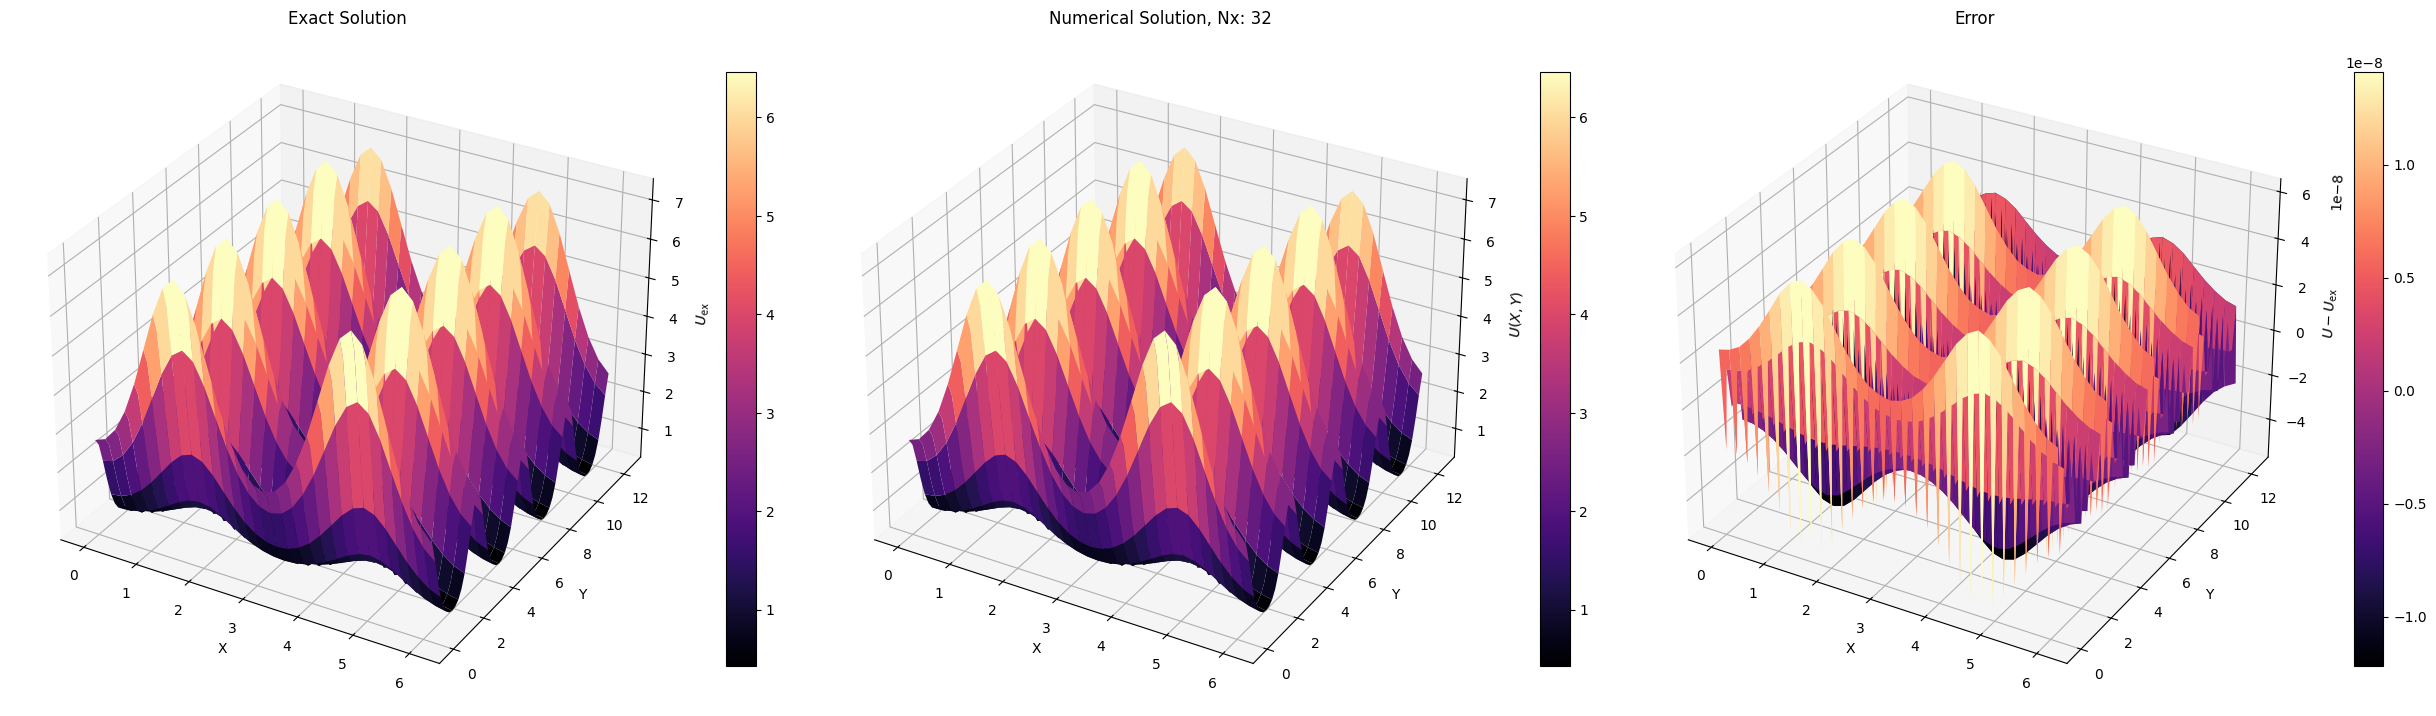

In [712]:
#surface plot:

def surface_plot(Nx,Lx,Ly,f,u,c):
    Ny = 2*Nx
    x = np.linspace(0,Lx,Nx, endpoint=False)
    y = np.linspace(0,Ly,Ny, endpoint=False)
    X,Y = np.meshgrid(x,y, indexing="ij")

    F = f(X,Y)
    U_ex = u(X,Y)
    U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c, mean = 0)
    U += np.mean(U_ex)
    U_err = U - U_ex

    fig = plt.figure(figsize=(25, 30))
    ax = fig.add_subplot(131, projection='3d')
    surf1 = ax.plot_surface(X, Y, U_ex, cmap='magma')
    fig.colorbar(surf1, shrink=0.2)
    ax.set_title("Exact Solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U_\mathrm{ex}$')

    ax = fig.add_subplot(132, projection='3d')
    surf2 = ax.plot_surface(X, Y,  U, cmap='magma')
    fig.colorbar(surf2, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title(f'Numerical Solution, Nx: {Nx}')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U(X, Y)$')

    ax = fig.add_subplot(133, projection='3d')
    surf3 = ax.plot_surface(X, Y,  U_err, cmap='magma')
    fig.colorbar(surf3, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title("Error")
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')
    plt.tight_layout()
    plt.show()

   


surface_plot(15,2*np.pi,4*np.pi,f1,u1,c=1)
surface_plot(16,2*np.pi,4*np.pi,f1,u1,c=1)
surface_plot(32,2*np.pi,4*np.pi,f2,u2,c=0)
